In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
import os
from os.path import join
import json
import pickle as pkl
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from tqdm.auto import trange, tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from easydict import EasyDict as edict
sys.path.append("/n/home12/binxuwang/Github/DiffusionLearningCurve")
sys.path.append("/Users/binxuwang/Github/DiffusionLearningCurve/")
from core.diffusion_nn_lib import UNetBlockStyleMLP_backbone
from core.toy_shape_dataset_lib import generate_random_star_shape_torch
from core.diffusion_basics_lib import *
from core.diffusion_edm_lib import *
from core.network_edm_lib import SongUNet, DhariwalUNet
from core.DiT_model_lib import *
from core.diffusion_nn_lib import UNetBlockStyleMLP_backbone
from core.trajectory_convergence_lib import analyze_and_plot_variance, fit_regression_log_scale
from circuit_toolkit.plot_utils import saveallforms, to_imgrid, show_imgrid
from pprint import pprint
from core.trajectory_convergence_lib import analyze_and_plot_variance, fit_regression_log_scale
from core.img_patch_stats_analysis_lib import compute_crossing_points, sweep_and_create_sample_store, process_img_mean_cov_statistics,\
     process_patch_mean_cov_statistics, plot_variance_trajectories, plot_mean_deviation_trajectories, \
     harmonic_mean, smooth_and_find_threshold_crossing
from core.trajectory_convergence_lib import analyze_and_plot_variance
from core.trajectory_convergence_lib import smooth_and_find_threshold_crossing, compute_crossing_points
from core.img_patch_stats_analysis_lib import plot_variance_trajectories

saveroot = f"/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionSpectralLearningCurve"

In [5]:
from einops import rearrange
def patch_mean_cov(X, P, device='cuda'):
    # X = data_Xtsr[1000:3000].cpu()
    # X = (X - 0.5) / 0.5
    # Y = data_Xtsr[1000:3000].cpu()
    C_out = X.shape[1]
    C_in = X.shape[1]
    # X: (N, C_in, H, W), Y: (N, C_out, H_out, W_out)
    unfold = torch.nn.Unfold(kernel_size=P, padding=P//2, stride=1)
    X_patches = unfold(X)
    print(X_patches.shape)
    # n_samples, n_patch_elements, n_positions = X_patches.shape
    X_patches_flatten = rearrange(X_patches, "n_sample n_element n_position -> (n_sample n_position) n_element").to(device)
    patch_mean = X_patches_flatten.mean(dim=0)
    patch_cov = torch.cov(X_patches_flatten.T).to(device)  # Transpose to get n_element by n_element covariance matrix
    return patch_mean, patch_cov


def patch_Gaussian_denoiser(patch_mean, patch_cov, noise_level, P, C_in, device='cuda', verbose=True):
    sigma = noise_level
    eye_mat = torch.eye(patch_cov.shape[0], device=device)
    patch_cov = patch_cov.to(device)
    patch_mean = patch_mean.to(device)
    denoiser_jacobian = patch_cov @ torch.linalg.inv(patch_cov + eye_mat * sigma ** 2)
    denoiser_bias = (eye_mat - denoiser_jacobian) @ patch_mean
    W_center = denoiser_jacobian.view(C_in, P, P, C_in, P, P)[:, P//2, P//2, :, :, :]
    b_center = denoiser_bias.view(C_in, P, P)[:, P//2, P//2]
    if verbose:
        print(W_center.shape)
        print(b_center.shape)
    return denoiser_jacobian, denoiser_bias, W_center, b_center


def compute_patch_Gaussian_denoiser(data_Xtsr, P, noise_level, device='cuda'):
    C_in = data_Xtsr.shape[1]
    print("Computing patch mean and covariance")
    patch_mean, patch_cov = patch_mean_cov(data_Xtsr, P, device="cpu")
    print("Computing patch Gaussian denoiser")
    denoiser_jacobian, denoiser_bias, W_center, b_center = patch_Gaussian_denoiser(patch_mean, patch_cov, noise_level, P, C_in, device=device)
    return denoiser_jacobian, denoiser_bias, W_center, b_center


def build_linear_conv_denoiser_layer(patch_mean, patch_cov, noise_level, P, C_in, device='cuda'):
    print("Computing patch Gaussian denoiser")
    denoiser_jacobian, denoiser_bias, W_center, b_center = patch_Gaussian_denoiser(patch_mean, patch_cov, noise_level, P, C_in, device=device)
    conv_GaussianPatch = torch.nn.Conv2d(C_in, C_out, kernel_size=P, padding=P//2, stride=1)
    conv_GaussianPatch.weight.data = W_center
    conv_GaussianPatch.bias.data = b_center
    return conv_GaussianPatch


def get_t_steps(sigma_min, sigma_max, num_steps, rho):
    step_indices = torch.arange(num_steps, dtype=torch.float32, device=device)
    t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
    return t_steps

In [ ]:
@torch.no_grad()
def edm_sampler(
    edm, latents, class_labels=None,
    num_steps=18, sigma_min=0.002, sigma_max=80, rho=7, 
    dtype=torch.float32, return_traj=False,
):
    # Adjust noise levels based on what's supported by the network.
    sigma_min = max(sigma_min, edm.sigma_min)
    sigma_max = min(sigma_max, edm.sigma_max)

    # Time step discretization.
    step_indices = torch.arange(num_steps, dtype=dtype, device=latents.device)
    t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
    # t_steps = torch.cat([edm.round_sigma(t_steps), torch.zeros_like(t_steps[:1])]) # t_N = 0
    t_steps = torch.cat([t_steps, torch.zeros_like(t_steps[:1])]) # t_N = 0
    
    x_traj = []
    denoiser_traj = []
    # Main sampling loop.
    x_next = latents.to(dtype) * t_steps[0]
    x_traj.append(x_next)
    for i, (t_cur, t_next) in enumerate(zip(t_steps[:-1], t_steps[1:])): # 0, ..., N-1
        x_hat = x_next
        t_hat = t_cur
        
        # Euler step.
        denoised = edm(x_hat, t_hat, class_labels, ).to(dtype)
        d_cur = (x_hat - denoised) / t_hat
        x_next = x_hat + (t_next - t_hat) * d_cur

        # Apply 2nd order correction.
        if i < num_steps - 1:
            denoised = edm(x_next, t_next, class_labels, ).to(dtype)
            d_prime = (x_next - denoised) / t_next
            x_next = x_hat + (t_next - t_hat) * (0.5 * d_cur + 0.5 * d_prime)
        x_traj.append(x_next)
        denoiser_traj.append(denoised)
    if return_traj:
        x_traj = torch.stack(x_traj, dim=0)
        denoiser_traj = torch.stack(denoiser_traj, dim=0)
        return x_next, x_traj, denoiser_traj, t_steps
    else:
        return x_next
    

In [6]:
@torch.no_grad()
def edm_sampler_with_linconv(
    linconv_denoiser_dict, latents, 
    num_steps=18, sigma_min=0.002, sigma_max=80, rho=7,
    dtype=torch.float32, return_traj=False,
):
    """
    EDM sampler that uses a dictionary of linear convolutional denoisers for different noise levels.
    
    Args:
        linconv_denoiser_dict (dict): Dictionary mapping noise levels to convolutional denoisers
        latents (torch.Tensor): Initial noise tensor
        num_steps (int): Number of sampling steps
        sigma_min (float): Minimum noise level
        sigma_max (float): Maximum noise level
        rho (float): Noise schedule parameter
        dtype (torch.dtype): Data type for computation
        return_traj (bool): Whether to return the full trajectory
        
    Returns:
        Final sample or (final sample, trajectory, denoiser outputs, time steps)
    """
    device = latents.device
    
    # Time step discretization
    step_indices = torch.arange(num_steps, dtype=dtype, device=device)
    t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
    t_steps = torch.cat([t_steps, torch.zeros_like(t_steps[:1])])  # t_N = 0
    
    x_traj = []
    denoiser_traj = []
    
    # Main sampling loop
    x_next = latents.to(dtype) * t_steps[0]
    x_traj.append(x_next)
    
    for i, (t_cur, t_next) in enumerate(zip(t_steps[:-1], t_steps[1:])):  # 0, ..., N-1
        x_hat = x_next
        t_hat = t_cur
        
        # Find closest noise level in the dictionary
        closest_noise_level = min(linconv_denoiser_dict.keys(), key=lambda k: abs(k - t_hat.item()))
        denoiser = linconv_denoiser_dict[closest_noise_level]
        
        # Euler step
        denoised = denoiser(x_hat)
        d_cur = (x_hat - denoised) / t_hat
        x_next = x_hat + (t_next - t_hat) * d_cur

        # Apply 2nd order correction
        if i < num_steps - 1:
            closest_noise_level = min(linconv_denoiser_dict.keys(), key=lambda k: abs(k - t_next.item()))
            denoiser = linconv_denoiser_dict[closest_noise_level]
            denoised = denoiser(x_next)
            d_prime = (x_next - denoised) / t_next
            x_next = x_hat + (t_next - t_hat) * (0.5 * d_cur + 0.5 * d_prime)
            
        x_traj.append(x_next)
        denoiser_traj.append(denoised)
        
    if return_traj:
        x_traj = torch.stack(x_traj, dim=0)
        denoiser_traj = torch.stack(denoiser_traj, dim=0)
        return x_next, x_traj, denoiser_traj, t_steps
    else:
        return x_next

### FFHQ32 dataset

In [7]:
import sys
from os.path import join
sys.path.append("/n/home12/binxuwang/Github/edm")
from training.dataset import TensorDataset, ImageFolderDataset
sys.path.append("/n/home12/binxuwang/Github/DiffusionLearningCurve")
from core.dataset_lib import load_dataset
edm_dataset_root = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/Datasets/EDM_datasets/datasets"
import torch
Xtsr_raw, imgsize = load_dataset("ffhq-32x32", normalize=True)

/n/home12/binxuwang/Github/DiffusionLearningCurve/core/dataset_lib.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Xtsr_raw = torch.load(join(word_dataset_root, "ffhq-3

ffhq-32x32 dataset: torch.Size([70000, 3, 32, 32])
Raw value range 1.0 0.0
Normalizing dataset to [-1.0, 1.0]


In [8]:
X_mean = Xtsr_raw.mean(dim=0)
X_cov = torch.cov(Xtsr_raw.flatten(start_dim=1).cuda().T)
eig_vals, eig_vecs = torch.linalg.eigh(X_cov)

In [9]:
Xtsr32_5000 = Xtsr_raw[:5000] # this is after preprocessing
P = 19
# noise_level = 5.0
device = "cpu"
X = Xtsr32_5000
C_out = X.shape[1]
C_in = X.shape[1]
# X: (N, C_in, H, W), Y: (N, C_out, H_out, W_out)
unfold = torch.nn.Unfold(kernel_size=P, padding=P//2, stride=1)
X_patches = unfold(X)
print(X_patches.shape)
# n_samples, n_patch_elements, n_positions = X_patches.shape
X_patches_flatten = rearrange(X_patches, "n_sample n_element n_position -> (n_sample n_position) n_element").to(device)
patch_mean = X_patches_flatten.mean(dim=0)
patch_cov = torch.cov(X_patches_flatten.T).to(device)  # Transpose to get n_element by n_element covariance matrix
# denoiser_jacobian, denoiser_bias, W_center, b_center = compute_patch_Gaussian_denoiser(Xtsr64_1000, P, noise_level, device='cpu')
# train_patche_bank = X_patches_flatten.to(torch.float16).cuda()

torch.Size([5000, 1083, 1024])


In [27]:
t_steps = get_t_steps(0.002, 80, 35, 7)
device = "cuda"
linconv_denoiser_dict = {}
for noise_level in t_steps:
    denoiser_jacobian, denoiser_bias, W_center, b_center = patch_Gaussian_denoiser(patch_mean, patch_cov, noise_level, P, C_in, device=device)
    # denoiser_jacobian, denoiser_bias, W_center, b_center = compute_patch_Gaussian_denoiser(Xtsr64_1000, P, noise_level, device='cpu')
    # build conv model
    conv_GaussianPatch = torch.nn.Conv2d(C_in, C_out, kernel_size=P, padding=P//2, stride=1)
    conv_GaussianPatch.weight.data = W_center.to(device)
    conv_GaussianPatch.bias.data = b_center.to(device)
    linconv_denoiser_dict[noise_level.item()] = conv_GaussianPatch.to(device)

torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size([3, 3, 13, 13])
torch.Size([3])
torch.Size(

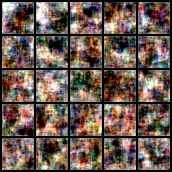

In [28]:
samples = edm_sampler_with_linconv(linconv_denoiser_dict, torch.randn(25, 3, 32, 32).cuda(), 
                         num_steps=35, sigma_min=0.002, sigma_max=80, rho=7)
to_imgrid(((samples + 1) * 0.5).clamp(0, 1), nrow=5)